<h1><center>MS BGD - TP Avazu<center></h1>


# Introduction

In online advertising, click-through rate (CTR) is a very important metric for evaluating ad performance. As a result, click prediction systems are essential and widely used for sponsored search and real-time bidding. The goal of this TP is to build and test prediction models on 11 days of Avazu data.



In [1]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve

AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]


if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    print('Extracting to %s...' % AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

<font color="red">**Question:**
    Import the needed packages: numpy, pandas etc..
</font>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
%matplotlib inline

# The dataset

<font color="red">**Question:**
Load the data *'train-1000000'* into a pandas DataFrame. Then, display the first lines with the ".head()" method.
</font>
**Remark**: the features meaning is available at https://www.kaggle.com/c/avazu-ctr-prediction/data

In [3]:
df = pd.read_csv( 'train-1000000' )

In [4]:
df.head() 

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23


<font color="red">**Question:**
    What is the 'click' frequency in the dataset?
    <br>
    Hint: 'click' is a binary output (0 or 1)
</font>

In [5]:
df['click'].value_counts()

click
0    830029
1    169971
Name: count, dtype: int64

We note that the Avazu dataset is very unbalanced. The 'click' class represents less than a fifth of the whole database. We already know that a classifier always predicting 'click'=0 will have good preformances in terms of error rate (around 0.17). The ROC curve will be better performance metrics.

<font color="red">**Question:**
    What are the categorical features? Using the 'df.nunique()' method, compute the number of distincts values for each of these features.
</font>

In [6]:
for col in df.columns:
    n_unique=df[col].nunique()
    print("column:",col, "unique values:", n_unique)

column: id unique values: 1000000
column: click unique values: 2
column: hour unique values: 240
column: C1 unique values: 7
column: banner_pos unique values: 7
column: site_id unique values: 2651
column: site_domain unique values: 2871
column: site_category unique values: 22
column: app_id unique values: 3157
column: app_domain unique values: 198
column: app_category unique values: 26
column: device_id unique values: 150501
column: device_ip unique values: 555248
column: device_model unique values: 5168
column: device_type unique values: 5
column: device_conn_type unique values: 4
column: C14 unique values: 2243
column: C15 unique values: 8
column: C16 unique values: 9
column: C17 unique values: 420
column: C18 unique values: 4
column: C19 unique values: 66
column: C20 unique values: 163
column: C21 unique values: 60


<font color="red">**Question:**
    If one does a dummy encoding of all categorical variables, what would be the dimension of the model?
    In other words: what would be the dimension of our big feature vector encoded with dummies.
    <br>
    Hint: if you have just 1 feature with 3 categories A, B and C, you would have a vector of dimension 3 (or 2 if you use drop_first=True).
</font>

In [7]:
a=0
for k in range(0,df.columns.size):
    a+=df[df.columns[k]].nunique()
print(a)

1723080


Your answer here

The dimension of the model would be 1 723 080

<font color="red">**Question:**
    Analyze the 'hour' column: which format is used? How can we transform/simply this feature?
</font>

In [8]:
print(df[ "hour" ].head()) # Fill here
print(df[ "hour" ].tail()) # Fill here

0    14102915
1    14103007
2    14102711
3    14102903
4    14102902
Name: hour, dtype: int64
999995    14102602
999996    14102101
999997    14102318
999998    14102908
999999    14102600
Name: hour, dtype: int64


Your answer here

We have the format YYMMDDHH. 

<font color="red">**Question:**
    Run and understand the following script.
</font>

In [9]:
import datetime

def datesplit(originalDate):
    originalDate = str(originalDate)

    year = int("20" + originalDate[0:2])
    month = int(originalDate[2:4])
    day = int(originalDate[4:6])
    hour = int(originalDate[6:8])

    return datetime.datetime(year, month, day, hour)

# Exemple :
datesplit(14102915).weekday(), datesplit(14102915).hour

(2, 15)

<font color="red">**Question:**
    Using the ".apply( ... )" method, create a 'weekday' for the day of the week. Then, replace the 'hour' column by the hour.
</font>

To answer this question you have to understand that applies takes a function as argument
<br>
"lambda x: ... " is used to create local unamed function of x
<br>
Check the documentation: https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions

In [10]:
df['weekday'] = df['hour'].apply(lambda x: datesplit(x).weekday() ) # Fill here
df['hour'] = df['hour'].apply(lambda x: datesplit(x).hour ) # Fill here

<font color="red">**Question:**
    Using the ".groupby( ... )" method, visualize the influence of the hour and of the day on the 'click' frequency (take the ".mean()"!). To do so, plot 'click' vs 'hour' and 'click' vs 'weekday' curves.
    <br>
    Precise the name of the axes.
</font>

In [11]:
print(df.groupby( 'hour' )[ 'click' ].mean()) # Fill here for the influence of the hour
print(df.groupby( 'weekday' )[ 'click' ].mean()) # Fill here for the influence of the day

hour
0     0.182707
1     0.185734
2     0.175552
3     0.175367
4     0.159664
5     0.162126
6     0.169315
7     0.177490
8     0.163418
9     0.159042
10    0.162613
11    0.171025
12    0.171659
13    0.168032
14    0.178075
15    0.183737
16    0.180076
17    0.173271
18    0.164072
19    0.165725
20    0.158402
21    0.162384
22    0.166847
23    0.170733
Name: click, dtype: float64
weekday
0    0.183143
1    0.161577
2    0.158675
3    0.173795
4    0.173392
5    0.183995
6    0.183105
Name: click, dtype: float64


# Preliminary work and first model

Start by understanding the features with few modalities:
'hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21'.

<font color="red">**Question:**
    For instance, inspect the columns 'C15' (dimension of the advert) and 'site_category': visualize the clicks mean.
</font>

In [12]:
df.groupby('C15')['click'].mean() # Fill here: inspect 'C15' using '.groupby'

C15
120     0.033708
216     0.129612
300     0.360537
320     0.158767
480     0.285714
728     0.054144
768     0.375000
1024    0.166667
Name: click, dtype: float64

In [13]:
df.groupby('site_category')['click'].mean() # Fill here: inspect 'site_category' using '.groupby'

site_category
0569f928    0.053613
28905ebd    0.208076
335d28a8    0.089824
3e814130    0.284245
42a36e14    0.225806
50e219e0    0.128597
5378d028    0.000000
70fb0e29    0.144737
72722551    0.059172
75fa27f6    0.111305
76b2941d    0.035756
8fd0aea4    0.015873
9ccfa2ea    0.000000
a818d37a    0.000000
bcf865d9    0.000000
c0dd3be3    0.128655
c706e647    0.000000
da34532e    0.000000
dedf689d    0.530449
e787de0e    0.000000
f028772b    0.179719
f66779e6    0.034564
Name: click, dtype: float64

<font color="red">**Question:**
    Some site categories have a null click rate. Why? Display the 'count()' of each modality.
    <br><br>
    Hint: you can use the method ".value_counts()"
</font>

In [14]:
df['site_id'].value_counts() # Fill here

site_id
85f751fd    360911
1fbe01fe    159924
e151e245     65231
d9750ee7     24090
5b08c53b     22524
             ...  
cc26ad12         1
527dc054         1
1d612678         1
bfec68aa         1
66095cf2         1
Name: count, Length: 2651, dtype: int64

It is practical to visualize both columns in parallel:

In [15]:
col = 'site_category'
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'count']
a.sort_values(by='count', ascending=False)

,mean,count
site_category,,
50e219e0,0.128597,408921.0
f028772b,0.179719,313339.0
28905ebd,0.208076,182020.0
3e814130,0.284245,75667.0
f66779e6,0.034564,6365.0
75fa27f6,0.111305,4007.0
335d28a8,0.089824,3351.0
76b2941d,0.035756,2573.0
c0dd3be3,0.128655,1026.0


Your answer here

That may be normal for a website to have no clicks if it is not visited often or poor ads quality/irrrelevant ads... 
So the count of each modality will help to understand if the null click rate is due to a low number of visits or if it is really a non-clicked site category.
We see here the site with 0 as a click rate have a very low count (less than 60)

<font color="red">**Question:**
    Divide the dataset into a training and test set with sklearn (use the following options: test_size=0.1, random_state=100).
    <br>
    Warning: do not use 'id' as a feature.
</font>

In [16]:
from sklearn.model_selection import train_test_split
newdf=df.drop(columns=['id','click'])
Xtrain, Xtest, ytrain, ytest = train_test_split(newdf, df['click'], test_size=0.1, random_state=100)

# First work on a reduced number of features

<font color="red">**Question:**
    Put in a list the selected columns: 'hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21'.
</font>

In [17]:
some_columns = ['hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category',
                'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21']

<font color="red">**Question:**
    <br>
    - Import OneHotEncoder from sklearn.preprocessing
    <br>
    - Transform the training and the test data restricted to the selected columns
</font>

In [18]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
Xtrain_oh = ohe.fit_transform(Xtrain[some_columns])
Xtest_oh = ohe.transform(Xtest[some_columns])

Xtrain_oh.shape, Xtest_oh.shape

((900000, 183), (100000, 183))

ohe.fit_transform(Xtrain[selected_columns])
Fit (Apprentissage) : L'encodeur parcourt Xtrain pour recenser toutes les catégories uniques (ex: "Paris", "Lyon", "Marseille"). Il enregistre ce "vocabulaire".

Transform (Transformation) : Il convertit les données en une matrice binaire (0 ou 1).
Donc pour chaquel label on crée une colonne.

<font color="red">**Question:**
    What is the new number of features?
</font>

In [19]:
print("there is:", Xtrain_oh.shape[1], "features after one-hot encoding.")

there is: 183 features after one-hot encoding.


Your answer here

183 features!

<font color="red">**Question:**
    Visualize the first row of the design matrix you have got. Do not forget to convert it into a "numpy.array" using the method ".toarray()".
</font>

In [20]:
Xtrain_oh[0].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.]])

<font color="red">**Question:**
    Import and fit a logistic regression model on your the encoded data.
</font>

In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(Xtrain_oh, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<font color="red">**Question:**
    With '.predict' and 'predict_proba', display the hard and soft decision you get on test data.
</font>

In [22]:
hard = lr.predict(Xtest_oh)
soft = lr.predict_proba(Xtest_oh) #first row is prob of class 0, second row is prob of class 1
print(soft)

[[0.75735121 0.24264879]
 [0.73281609 0.26718391]
 [0.79536358 0.20463642]
 ...
 [0.79240124 0.20759876]
 [0.78378158 0.21621842]
 [0.87883768 0.12116232]]


<font color="red">**Question:**
    Compute the probability of error using sklearn.metrics 'accuracy_score' function. Comment.
</font>

In [23]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(ytest, hard))
df['click'].value_counts()

Accuracy: 0.83045


click
0    830029
1    169971
Name: count, dtype: int64

Your answer here

We get an accuracy of around 0.83 which is pretty good but as the dataset is unbalanced it is not a good metric to evaluate the model performance since the dataset has around 83percent of non clicks, we could just predict non clicks and get the same accuracy.

<font color="red">**Question:**
    Plot the ROC curve. Then compute the log loss and the Area Under the Curve ROC.
</font>

Text(0.5, 1.0, 'ROC curve')

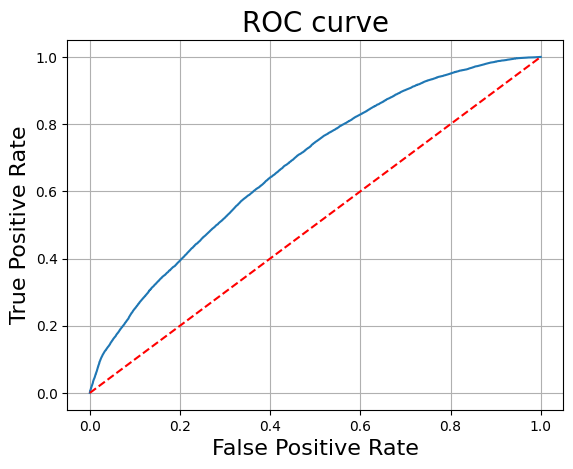

In [24]:
from sklearn.metrics import roc_curve

false_pos_rate, true_pos_rate, _ = roc_curve( ytest, soft[:,1] )
plt.plot(false_pos_rate, true_pos_rate)

plt.grid()
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve', fontsize=20)

Log loss evaluates the quality of predicted probabilities (penalizes confident wrong predictions), which matters for ranking/CTR.

ROC AUC measures how well the model separates clicks vs non-clicks, independent of any threshold and less sensitive to class imbalance.

In [25]:
from sklearn.metrics import log_loss, roc_auc_score
log_loss( ytest, soft[:,1] ), roc_auc_score( ytest, soft[:,1] )

(0.4251789966300482, 0.676061763713435)

# Complete model

As an example, we now focus on the 'site_id' column.

<font color="red">**Question:**
    <br>
    - For each modality, compute the number of occurrences in the dataset and the average of clicks for this modality
    <br>
    - With 'sns.joiplot', represent the set of points (count, mean) for each modality
</font>

In [26]:
import seaborn as sns

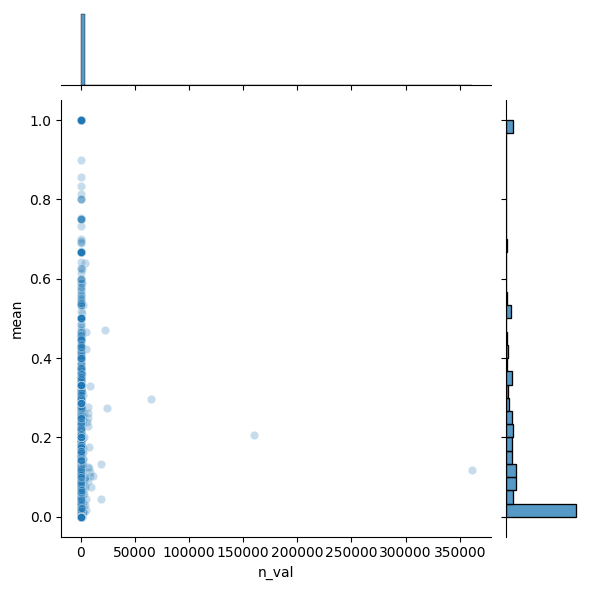

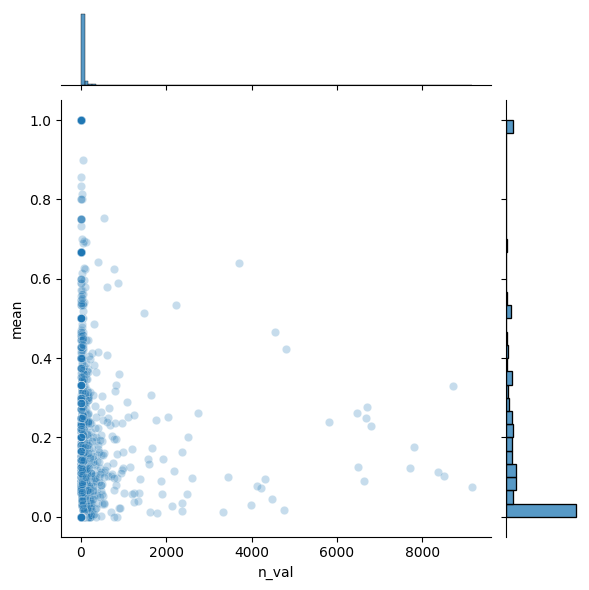

In [27]:
col = 'site_id'
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'n_val']
sns.jointplot(x=a['n_val'], y=a['mean'], alpha=0.25);
thres = 10000
sns.jointplot(x=a[a['n_val']<thres]['n_val'], y=a[a['n_val']<thres]['mean'], alpha=0.25);

<font color="red">**Question:**
    In the above commands, what does the alpha parameter stand for?
</font>

Your answer here

The alpha parameter controls the point transparency (0 = fully transparent, 1 = fully opaque), helping reduce overplotting.

Several sites with a lot of occurrences in the dataset have a click frequency very different from the mean. It is relevant to keep the column 'site_id' at least for the modalities for which 'count' is very high.

<font color="red">**Question:**
    Do the same work on the 'device_id' column. What do you notice? What could be the isolated point?
</font>

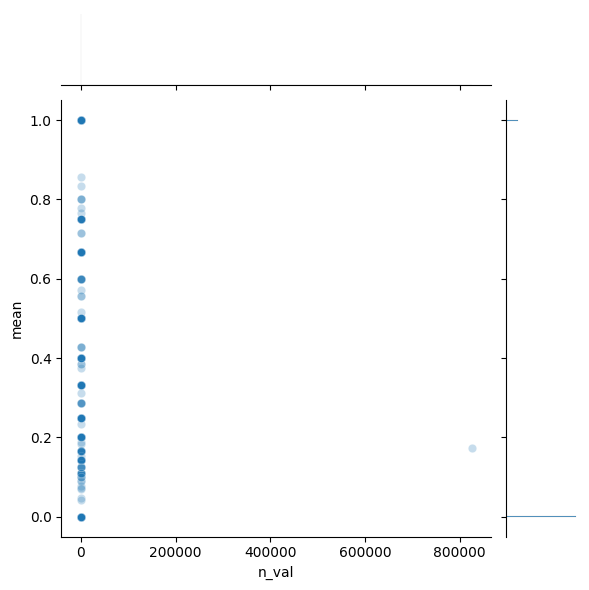

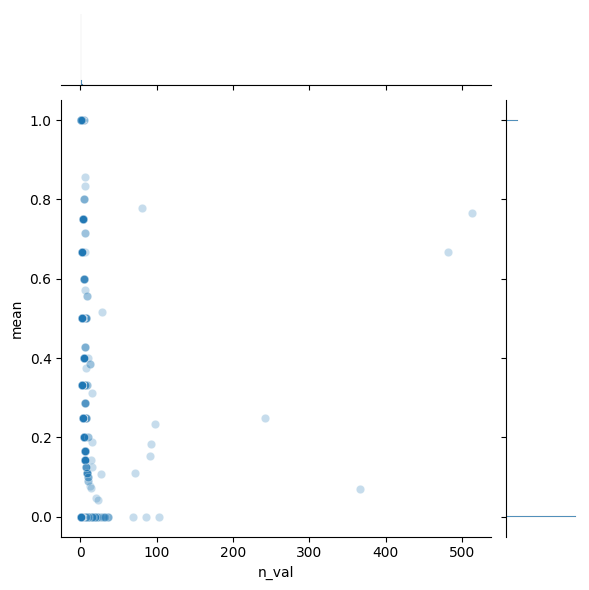

In [28]:
col = "device_id" # Fill here
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'n_val']
sns.jointplot(x=a['n_val'], y=a['mean'], alpha=0.25);
thres = 10000
sns.jointplot(x=a[a['n_val']<thres]['n_val'], y=a[a['n_val']<thres]['mean'], alpha=0.25);

Your answer here

there is one device id with a very high click rate and a very high count, it could be a bot or a very active user.


<font color="red">**Question**:   
    In the column df['device_id'], spot the value V corresponding to the largest number of 'count' (using '.value_counts' method). Create a new column df['user'] defined as follows:
</font>
$$
\text{user} = \left\{ \begin{array}{ll} \text{device\_ip + device\_model} & \text{if device\_id = V} \\ \text{device\_id} & \text{else} \end{array} \right.
$$

In [29]:
V = df['device_id'].value_counts().index[0]
print(V)
df["user"] = df["device_id"].where(
    df["device_id"] != V,
    df["device_ip"].astype(str) + df["device_model"].astype(str)
)

a99f214a


<font color="red">**Question**:
    Drop in place the following columns: 'device_id', 'device_model' and 'device_ip'
</font>

In [30]:
df.drop(columns=["device_id","device_model","device_ip"], inplace=True) #Fill here

<font color="red">**Question**:
    One could look at the similarity between 'site_id' and 'site_domain'. Merge those columns into a new 'site' column (using the '+' operator)  and delete the old 'site_id' and 'site_domain' columns.
</font>

In [31]:
df['site'] = df['site_id'] + df['site_domain']
df.drop(columns=["site_id","site_domain"], inplace=True) #Fill here

<font color="red">**Question**:
    Once again, split the modified DataFrame 'df' into a train and a test set (with options: test_size=0.1 and random_state=100).
    <br>
    Warning: do not use 'id' as a feature.
</font>

In [32]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(columns=['id','click']), df['click'], test_size=0.1, random_state=100)

<font color="red">**Question**:
    Define a OneHotEncoder and then, 'fit_transform' the train set.
</font>

In [33]:
ohe = OneHotEncoder(handle_unknown='ignore')
Xtrain_oh = ohe.fit_transform(Xtrain)

<font color="red">**Question**:
    Transform the test set. If an error occurs, analyze it and try to solve it by modifying the parameter "handle_unkown" of the OneHotEncoder.
    <br>
    Explain your the problem you encouter and how you solved it.
</font>

In [34]:
Xtest_oh = ohe.transform(Xtest)

Your answer here

i had to set handle_unknown='ignore' in the OneHotEncoder to avoid an error when transforming the test set because it contains categories that were not seen in the training set. This way, the encoder will ignore those unseen categories and not raise an error.

<font color="red">**Question**:
    What is the new number of features?
</font>

In [35]:
Xtrain_oh.shape, Xtest_oh.shape
print("the new number of features is", Xtrain_oh.shape[1])

the new number of features is 713334


Your answer here

The new number of features is 713334

<font color="red">**Question**:
    How many modalities have been seen more than a 100 times?
</font>

In [36]:
# The following 'n_ones' vector below gives the number of '1' in each column of the Xtrain_oh design matrix.
n_ones = np.array(Xtrain_oh.sum(axis=0)) #.ravel() to convert the result to a 1D array
nbre_modalities = 0
for k in range(0, Xtrain_oh.shape[1]):
    if n_ones[0][k]>100:
        nbre_modalities+=1
print("the number of modalities with more than 100 occurrences is", nbre_modalities)

the number of modalities with more than 100 occurrences is 1971


Your answer here

the number of modalities with more than 100 occurrences is 1971

The list 'cols_to_keep' below is used to store the indices of the modalities seen more than a 100 times.

<font color="red">**Remark**:
    Note how the `enumerate` function works
</font>

In [37]:
useful = np.array(n_ones>100)[0]
print(useful)
cols_to_keep = [i for i,b in enumerate(useful) if b] 
print(len(cols_to_keep))

[ True  True  True ... False False False]
1971


Your answer here

Emurate function allows us to loop over something and have an automatic counter. So in this case, we loop over the n_ones array and for each modality we check if it has more than 100 occurrences, if it does we add its index to the list 
cols_to_keep.
On cherche à savooir les features/modalities that are useful for our model, we consider that the modalities with less than 100 occurrences are not useful.

<font color="red">**Question**:
    Using only our restriction on the 'cols_to_keep' columns, retrain a logistic regression model and compare its performance in terms of 'log_loss' and 'roc_auc_curve'.
</font>

In [38]:
lr = LogisticRegression(max_iter=1000)
lr.fit(Xtrain_oh[:,cols_to_keep], ytrain)
soft = lr.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
print(soft[:5])


log_loss( ytest, soft ), roc_auc_score( ytest, soft )

[0.32565151 0.54565774 0.09884535 0.10613886 0.15793363]


(0.4014736823867585, 0.7381662574522853)

We see that the AUC has increased and the log loss has decreased, so the model is much better with the restriction on the columns.

# Gradient Boosting Decision Trees

<font color="red">**Question**:
    <br>
    - Import GradientBoostingClassifier from scikit learn.
    <br>
    - Initialize it using 50 estimators and a learning rate of 0.8. Set 'verbose=True' to monitor the progress of the training step.
    <br>
    - Fit it on the same columns 'cols_to_keep' of Xtrain_oh than for the previous logistic regression.
    <br>
    - Evaluate its performance as in the previous step.
</font>

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.8)

In [40]:
gb.fit( Xtrain_oh[:,cols_to_keep], ytrain )

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.8
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [41]:
soft = gb.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)

(0.4091623534864227, 0.7252328290988748)

<font color="red">**Question**:
    What does the 'gb.estimators_' output?
</font>

In [42]:
gb.estimators_

array([[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x7FA8682D3B40)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
       

Your answer here

gb.estimators_ is a list of the fitted sub-estimators (decision trees) that make up the gradient boosting model. Each element in this list corresponds to one of the boosting iterations and contains the tree that was trained to correct the errors of the previous trees.

We now try to use the 'gb' classifier to generate features that will be relevant inputs for the logistic regression.

<font color="red">**Question**:
    With the 'gb.apply()' method, generate a transformation 'leafs_train' of the training set 'Xtrain_oh[:, cols_to_keep]' for which the n-th column corresponds to the number of the leaf returned by the estimator n.
</font>

L'idée est de faire du feature engineering en utilisant les arbres de décision du gradient boosting pour créer de nouvelles features (les numéros des feuilles) qui peuvent être utilisées par la régression logistique pour améliorer ses performances.
Pourquoi est ce meilleur? 

Les numéros des feuilles capturent des interactions complexes entre les features d'origine que les arbres de décision ont apprises. En utilisant ces numéros comme nouvelles features, la régression logistique peut exploiter ces interactions pour faire de meilleures prédictions, ce qui peut améliorer les performances du modèle par rapport à l'utilisation des features d'origine seules.

Transformation non-linéaire : Les feuilles capturent des interactions complexes que la régression logistique seule ne peut pas apprendre directement

In [47]:
# Test here the gb.apply method on Xtrain[:, cols_to_keep]
gb.apply(Xtrain_oh[:,cols_to_keep]).shape

gb.apply(Xtrain_oh[:,cols_to_keep])[:,:,0]

array([[ 3.,  3.,  3., ...,  3.,  3.,  3.],
       [ 3.,  3.,  3., ...,  3.,  3.,  3.],
       [ 3.,  3.,  3., ...,  3.,  3.,  3.],
       ...,
       [ 3.,  3.,  3., ...,  3.,  3.,  3.],
       [ 3.,  3.,  3., ...,  3.,  3.,  3.],
       [ 3., 13.,  3., ...,  3.,  3.,  3.]], shape=(900000, 50))

After your applied gb.apply on Xtrain_oh[:, cols_to_keep], remember that we have only one class to predict (click = 0 or 1). So, do not forget to slice your output with [:, :, 0] in order to keep, firstly, all the samples, and secondly all your 50 estimators.

Hint: you can have a look at the dimensions of your output with .shape !

In [48]:
leafs_train = pd.DataFrame(gb.apply(Xtrain_oh[:,cols_to_keep])[:,:,0])
leafs_test = pd.DataFrame(gb.apply(Xtest_oh[:,cols_to_keep])[:,:,0])

<font color="red">**Question**:
    Encode these new features into dummies.
</font>

In [49]:
ohe = OneHotEncoder( handle_unknown='ignore' ) # Fill here an argument if needed
leafs_train_oh = ohe.fit_transform(leafs_train)
leafs_test_oh = ohe.transform(leafs_test)

<font color="red">**Question**:
    With the "hstack" function, create a new matrix of features by concatenating horizontally our new features "leafs_train_oh" and "leafs_test_oh", and previous features used for logistic regression (e.g. in "Xtrain_oh[:, cols_to_keep]").
</font>
<br><br>
**Remark**: we use "hstack" from scipy.sparse (and not from numpy) because the output of our OneHotEncoder is a sparse array. You can verify it with the command "type(Xtrain_oh)".

In [50]:
from scipy.sparse import csr_matrix, hstack

Xtrain_concat = hstack([Xtrain_oh[:,cols_to_keep], leafs_train_oh])
Xtest_concat = hstack([Xtest_oh[:,cols_to_keep], leafs_test_oh])

<font color="red">**Question**:
    Run a logistic regression on the new features and evaluate its performance as before.
    <br>
    Warning: be patient, fitting should take about 5 minutes on Google Colab.
</font>

In [52]:
lr1 = LogisticRegression(max_iter=1000)
lr1.fit(Xtrain_concat, ytrain)
soft = lr1.predict_proba(Xtest_concat)[:,1]
print(soft[:5])
    

log_loss( ytest, soft ), roc_auc_score( ytest, soft )

[0.29594003 0.48811123 0.0810536  0.10596778 0.15719058]


(0.4001276906794988, 0.7414971973256369)

# XGBoost

<font color="red">**Question**:
    <br>
    - Import XGBClassifier from xgboost package.
    <br>
    - Initialize it using the same number of estimators and learning rate as before. Set the 'n_jobs' to -1.
    <br>
    - Fit it on the same columns 'cols_to_keep' of Xtrain_oh than for the previous logistic regression.
    <br>
    - Evaluate its performance and compare it to the GradientBoosting classifier of scikit learn. How is the error? Does it take more time to run?
</font>

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=50, learning_rate=0.8, n_jobs=-1)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)

CPU times: user 22.6 s, sys: 461 ms, total: 23.1 s
Wall time: 2.35 s


(0.40437944030958095, 0.7341821918564987)

(0.40437944030958095, 0.7341821918564987) vs (0.4091623534864227, 0.7252328290988748) 

So we have a better performance with the GradientBoostingClassifier of scikit learn than with XGBoost, and it takes more time to run with XGBoost.

<font color="red">**Question**:
    Increase the number of estimators and visualize the impact on performance. You might have to adapt the learning rate. On Google Colab, here are the approximate training times<br>
    - nb_estimators=256  and lr=0.8 ~  4 min<br>
    - nb_estimators=512  and lr=0.6 ~  8 min<br>
    - nb_estimators=1024 and lr=0.5 ~ 16 min
</font>

In [58]:
xgb = XGBClassifier(n_estimators=256, learning_rate=0.8, n_jobs=-1)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)


CPU times: user 1min 21s, sys: 289 ms, total: 1min 22s
Wall time: 5.89 s


(0.40200650178693703, 0.7389766160753477)

In [59]:
xgb = XGBClassifier(n_estimators=512, learning_rate=0.6, n_jobs=-1)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)


CPU times: user 3min 24s, sys: 547 ms, total: 3min 24s
Wall time: 13.7 s


(0.3994218903510418, 0.7426312764552695)

In [60]:
xgb = XGBClassifier(n_estimators=1024, learning_rate=0.5, n_jobs=-1)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)


CPU times: user 6min 23s, sys: 736 ms, total: 6min 23s
Wall time: 25 s


(0.40010244583155324, 0.7419404512205243)

We see that increasing the number of estimators and decreasing the learning rate improves the performance of the model, but it also increases the training time significantly.

We need to fin a good balance...

# Features hashing and random forest

We restart with raw features before dummy encoding: Xtrain, Xtest.

<font color="red">**Question**:
    Display again the number of modalities per feature in Xtrain. Use '.nunique()'
</font>

In [63]:
a=0
for k in range(Xtrain.shape[1]):
    a+=Xtrain[Xtrain.columns[k]].nunique()
print(a)

713334


We want to define a transformation which regroups the least frequent modalities into a label 'isRare'. In order to do so, we decide to define our own Transformer.

<font color="red">**Question**:
    Understand the different steps of 'fit' and 'transform'.
</font>

In [64]:
from sklearn.base import BaseEstimator, TransformerMixin

class MergeRareTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, col_names, threshold):
        self.col_names = col_names
        self.threshold = threshold

    def fit(self, X, y=None):

        X = pd.DataFrame(X)
        counts_dict_list = []
        ################## READ THIS #########################
        for i in range(len(self.col_names)):

            serie = X[self.col_names[i]].value_counts()  # Série des counts de chaque modalité
            rare_indexes = serie[serie<self.threshold[i]].index  # A quoi correspondent ces indices ?
            frequent_indexes = serie[serie>=self.threshold[i]].index  # A quoi correspondent ces indices ?
            dico = {x:'isRare' for x in rare_indexes}
            dico.update({x: str(x) for x in frequent_indexes})
            counts_dict_list.append(dico)   # Quel est le dictionnaire obtenu ?
        
        ######################################################

        self.counts_dict_list_ = counts_dict_list
        return self

    #le dico contient les modalités fréquentes et rares, avec comme valeur 'isRare' 
    #pour les modalités rares et la modalité elle même pour les modalités fréquentes.
    
    def transform(self, X):

        Xt = pd.DataFrame()
        ################## READ THIS #########################
        for col, count_dict in zip(self.col_names, self.counts_dict_list_):
            Xt[col] = X[col].apply(lambda x:count_dict[x] if x in count_dict else 'isRare')
            # A quoi sert le "else 'isRare'" dans la transformation de la colonne ?
        ######################################################

        return Xt
    
    #Le else 'isRare' traite les catégories inconnues du test set en les regroupant dans la catégorie "rare",
    #plutôt que de lever une erreur.


<font color="red">**Question:**
    <br>
    - Fit and transform the training set. To do so, merge all mmodalities occuring at least 20 times in each column.
    <br>
    - Transform the test set.
</font>

In [65]:
mg = MergeRareTransformer(col_names=Xtrain.columns, threshold=[20]*len(Xtrain.columns))
Xtrain_mg = mg.fit_transform(Xtrain)
Xtest_mg = mg.transform(Xtest)

<font color="red">**Question:**
   How many elements of the column Xtrain_mg['app_domain'] are now labeled as 'rare'? Use the '.value_counts()' method.
</font>

In [66]:
Xtrain_mg['app_domain'].value_counts()

app_domain
7801e8d9    606390
2347f47a    116467
ae637522     41928
5c5a694b     25289
82e27996     16869
d9b5648e     15709
0e8616ad     14784
b9528b13     14284
b8d325c3     11953
aefc06bd      6644
df32afa9      6412
33da2e74      5911
6f7ca2ba      4990
5b9c592b      2448
885c7f3f      1468
5c620f04      1419
45a51db4      1219
b5f3b24a      1093
813f3323       544
0654b444       514
isRare         513
ad63ec9b       388
c6824def       306
15ec7f39       275
a8b0bf20       266
99b4c806       219
828da833       185
448ca2e3       167
f2f777fb       157
43cf4f06       149
47464e95        99
d6feb1a4        95
2b627705        89
1ea19ec4        72
db829551        69
6a0a3a9d        59
18eb4e75        56
0d79ee56        53
9ec164d3        51
e5d5313f        46
b12ff13e        42
27ee373d        36
b408d42a        30
5ac0b939        28
1ed56ded        27
bb6bcbae        27
3feeed1e        26
15c23f8e        25
63f57be0        25
7eec2ab0        24
7a9371fa        21
dcdba109        20
a

there are 513 IsRare elements in the column Xtrain_mg['app_domain'].

<font color="red">**Question:**
   In the new train set, display the number of modalities for each feature.
</font>

In [69]:
for k in range(Xtrain_mg.shape[1]):
    print(Xtrain_mg[Xtrain_mg.columns[k]].value_counts())

hour
13    53250
9     51228
12    49002
14    48970
10    47714
8     47072
15    46183
11    45749
17    45369
16    45102
5     44045
4     42423
7     41141
6     39428
18    38864
3     31184
19    29596
2     27384
20    25134
1     22163
21    22041
22    19841
0     18913
23    18204
Name: count, dtype: int64
C1
1005    826870
1002     49319
1010     20142
1012      2570
1007       789
1001       194
1008       116
Name: count, dtype: int64
banner_pos
0    647489
1    250926
7       977
2       291
4       162
5       116
3        39
Name: count, dtype: int64
site_category
50e219e0    367996
f028772b    282094
28905ebd    163844
3e814130     67970
f66779e6      5719
75fa27f6      3609
335d28a8      3020
76b2941d      2335
c0dd3be3       929
72722551       614
dedf689d       567
70fb0e29       562
0569f928       387
8fd0aea4       165
a818d37a        74
42a36e14        57
isRare          31
e787de0e        27
Name: count, dtype: int64
app_id
ecad2386    575126
92f5800b     34739

Modalities are arbitrary object, such as '234', 'isRare', etc. We will now transorm them into integers with the hashing trick.

<font color="red">**Question:**
   To better understand how the 'hash' function is working, apply it to a string of your choice.
</font>

In [78]:
import hashlib
#hash( str("je suis moi" ) )
hash(str("a"))


-5212265304492790161

<font color="red">**Question:**
   Create two new datasets 'Xtrain_ha' and 'Xtest_ha' containing the output of the hashing process. Use the '.apply' method to transform iteratively the columns by mapping to each value its remainder in the euclidean division of the hash by 1000000.
   Example:
</font>
</font>
<p>
<center>
2060777048690<font color="red">918393</font>  -->  918393
</center>
Remark: do not forget that the function 'hash' has to take a string as input.

In [81]:
Xtrain_ha = pd.DataFrame()
Xtest_ha = pd.DataFrame()
for col in Xtrain_mg.columns:
    Xtrain_ha[col] = Xtrain_mg[col].apply(lambda x: hash(str(x)) % 1000000)  # Fill here defining a lambda function
    Xtest_ha[col] = Xtest_mg[col].apply(lambda x: hash(str(x)) % 1000000) 

<font color="red">**Question:**
   Visualize the content of the DataFrames you have obtained.
</font>

In [83]:
Xtrain_ha.head()

,hour,C1,banner_pos,site_category,app_id,app_domain,app_category,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,weekday,user,site
92438,72848,351496,260738,920770,616567,138470,979668,182568,45589,935542,300644,170239,190728,562790,897774,767006,593908,562790,793766,554839
60898,630085,31895,562790,920770,336855,704821,920929,260738,157567,935542,300644,170239,190728,562790,897774,767006,593908,260738,793766,554839
556199,182568,31895,562790,230711,243256,138470,355820,260738,157567,502519,300644,170239,645752,562790,633983,767006,662322,562790,793766,963641
193129,306320,31895,260738,230711,243256,138470,355820,260738,562790,792825,300644,170239,637863,562790,439579,748706,277748,260738,793766,50372
231985,902769,31895,562790,386569,243256,138470,355820,260738,562790,488925,300644,170239,190728,562790,897774,797579,593908,686458,793766,663360


<font color="red">**Question:**
    <br>
    - Train a RandomForestClassifier on Xtrain_ha and evaluate its performance on Xtest_ha. Chose 256 estimators, min_samples_leaf=20 and verbose=1 in order to monitor the fitting step. (If you have enough time, try later with 1024 estimators and min_samples_leaf=20).
    <br>
    - How do you fix 'n_jobs'?
</font>

In [84]:
from sklearn.ensemble import RandomForestClassifier # Fill here
rf = RandomForestClassifier(n_estimators=256, min_samples_leaf=20, verbose=1)
rf.fit(Xtrain_ha, ytrain)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  5.1min
[Parallel(n_jobs=1)]: Done 256 out of 256 | elapsed:  6.6min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",256
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

n_jobs should be set to -1 to use all the processors available.

In [85]:
soft = rf.predict_proba(Xtest_ha)[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done 256 out of 256 | elapsed:    4.8s finished


(0.40125157912792914, 0.7399666813883735)

<font color="red">**Question:**
   Compare with xgboost performance on the same hashed dataset, with n_estimators=256, n_jobs=-1, learning_rate=1.0. (If you have enough time try n_estimators=1024, n_jobs=-1, learning_rate=0.5, it will perform better than a Random Forest of 1024 trees).
</font>

In [86]:
xgb = XGBClassifier(n_estimators=256, learning_rate=1.0, verbose=1, n_jobs=-1)
%time xgb.fit(Xtrain_ha, ytrain) # the '%time' command will return the execution time of the fitting step
soft = xgb.predict_proba(Xtest_ha)[:,1]
log_loss(ytest, soft), roc_auc_score(ytest, soft)

/home/elkou/MLTP/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:16:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CPU times: user 1min 35s, sys: 175 ms, total: 1min 36s
Wall time: 6.37 s


(0.40998581608143647, 0.7293254030848488)

<font color="red">**Question:**
    Plot the ROC curve for the obtained classifier (xgboost on hashed data).
</font>

Xgboost quicker but the performance is better with the random forest.

Good job! :-)

<font color="red">**Bonus Question:**
    If you have enough time (about 2 hours ...), try to fit both random forest and xgboost models with more estimators (and a different learning rate of 0.5 for xgboost) on these enlarged datasets.<br>
</font>

In [ ]:
# Fill here

# BONUS : Field-aware Factorization Machines
<br>
<font color="red">
Display the names of the columns of the matrix Xtrain_ha
</font>

<font color="red">
Create a list of lists of the columns. The n-th sub-list is composed of the names of the columns of the n-th field.</font>

In [ ]:
fields = []
fields.append( liste_colonnes_du_premier_champ )
fields.append( liste_colonnes_du_deuxième_champ )
fields.append( etc. )


<font color="red">
With the enumerate function, let generate a dictionary which associates each column name with its field.


In [ ]:
dicFields = { ... : ...  for i,f in enumerate(fields) for name_col in f}

We need to make sure that two different columns have different modalities. For this, we add in front of each modality a characteristic string of the column.

<font color="red">Perform this transformation with the apply method</font>


In [ ]:
Xtrain_ffm = pd.DataFrame()
Xtest_ffm = pd.DataFrame()
for col in Xtrain_ha.columns:
    Xtrain_ffm[col] = Xtrain_ha[col].apply( ... )
    Xtest_ffm[col] = Xtest_ha[col].apply( ... )

With np.unique, we create the list of all the modalities appearing in all the columns.

In [ ]:
allvals = []
allcols_ffm = [col for f in fields for col in f]  # Toutes les colonnes appartenant à l'un des champ
for col in allcols_ffm:
    allvals.append(np.unique(Xtrain_ffm[col]))
allvals= [val for sublist in allvals for val in sublist]

<font color="red">
Using enumerate method, create a dictionary that at each value associates its rank in the allvals list.</font>

In [ ]:
dicFeat = {val:i for i,val in ... }

We build dataframe from dicFeat as follows:
in each "col" column, the value "x" is replaced by the string "f: v: 1", where f is the field associated with the column and v is the index of the modality x.
<font color="red">
Study the following code</font>

In [ ]:
for col in allcols_ffm:
    f = dicFields[col]
    Xtrain_ffm[col] = Xtrain_ffm[col].apply(lambda x:"{}:{}:1".format(f,dicFeat[x]) if x in dicFeat else "")
    Xtest_ffm[col] = Xtest_ffm[col].apply(lambda x:"{}:{}:1".format(f,dicFeat[x]) if x in dicFeat else "")

<font color="red">For the two resulting dataframes, concatenate on the left the corresponding ytrain (or ytest) click column</font>

In [ ]:
yXtrain_ffm = pd.concat( ... ,axis=1)
yXtest_ffm = pd.concat( ... ,axis=1)

<font color="red">What does the following cell produce?</font>

In [ ]:
train_w = yXtrain_ffm.apply(lambda row:' '.join(row.values),axis=1).values
test_w = yXtest_ffm.apply(lambda row:' '.join(row.values),axis=1).values

<font color="red">Write the above dataframe in a text file</font>

In [ ]:
thefile = open('train.txt','w')
for item in train_w:
    thefile.write("%s\n" % item)

# Faire de même pour le test set


To learn the FFM model, we use the LibFFM library https://www.csie.ntu.edu.tw/~cjlin/libffm/
In the notebooks / directory there are two executables: ffm-train and ffm-predict.
In jupyter notebook, the exclamation point! allows to launch a bash command.
The use is as follows:

-   `ffm-train'

    usage: ffm-train [options] training_set_file [model_file]

    options:  
    -l <lambda>: set regularization parameter (default 0.00002)  
    -k <factor>: set number of latent factors (default 4)  
    -t <iteration>: set number of iterations (default 15)  
    -r <eta>: set learning rate (default 0.2)  
    -s <nr_threads>: set number of threads (default 1)  
    -p <path>: set path to the validation set  
    --quiet: quiet model (no output)  
    --no-norm: disable instance-wise normalization  
    --auto-stop: stop at the iteration that achieves the best validation loss (must be used with -p)  
<br>
<font color="red">Learn the model. We can :
- use an regularizer of 0.00001
- use a learning rate of 0.05
- use of the order of 15 latent factors
- carry out the order of 30 iterations
- with the -p option, change the test file to validation parameters
- activate the --autostop mode
</font>

The use of ffm-predict is: ffm-predict filename-test file-name-model file-in-which-write-the-prediction
<font color="red">Perform the prediction</font>

<font color="red">Compute the log_loss and area under the roc curve (ROC AUC).</font>

# Bonus 2 : blending

<font color="red">
Split Xtrain in two: Xtrain_meth and Xtrain_blend.</font>

In [ ]:
Xtrain_meth, Xtrain_blend, ytrain_meth, ytrain_blend = train_test_split(Xtrain_ha,ytrain,test_size=0.2)

<font color="red">
Train a logistic regression on XTrain_meth. Then compute its score on Xtrain_blend and save the score in a vector.</font>

<font color="red">
Do the same thing with XGBoost (save the score).</font>

<font color="red">
Do the same with a RandomForest (save the score).</font>

<font color="red">
Now with an extraTrees.</font>

<font color="red">
And again with FFM.</font>

<font color="red">
Concatenate all scores on Xtrain_blend to form a Zblend design matrix.</font>

<font color="red">
Train a logistic regression on (Zblend,ytrain_blend).</font>

<font color="red">
Evaluate the performance of this model on the test dataset.</font>